# EDA — `branches`: business opportunities in the physical network

**Hypothesis.** The physical network (350 branches, ATMs and teller windows) holds opportunities: rebalancing branches
where customers are under-served, reallocating ATM and teller capacity to where demand is, adjusting opening hours,
closing or reopening branches, and fixing service hot spots.

**Questions.**

1. What does the branch network look like (size, mix, capacity, density per city) and is the file trustworthy?
2. Which datasets link to a branch, and how reliable are those links?
3. Does demand (transactions, products opened, complaints, delinquency) differ between branches, and does it follow
   the branch's type, capacity, city, status or age?
4. Are there real opportunities, or is the value in fixing the data first?

Scope: `data/branches.csv` joined to products, customers, complaints and the full transaction history (1,097 daily
files, streamed one at a time so memory stays small). Descriptive only, no model. Nothing is imputed or invented.

## 1. Setup and load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
BRANCHES_PATH = REPO_ROOT / "data" / "branches.csv"
DATA_DIRECTORY = REPO_ROOT / "data" / "data"
TRANSACTIONS_ROOT = REPO_ROOT / "data" / "transactions"
COMPLAINTS_ROOT = REPO_ROOT / "data" / "complaints"

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"
TRANSACTION_COLUMNS = ["transaction_date", "channel", "branch_id", "transaction_type", "currency", "amount", "amount_usd"]
PHYSICAL_CHANNELS = ["ATM", "Branch"]
REFERENCE_DATE = pd.Timestamp("2026-06-17")


def current_memory_mb() -> float:
    """Measures the resident memory of this notebook's process.

    Exists to show the streaming approach stays small on a machine with limited free RAM.

    Args:
        None.

    Returns:
        float: resident set size in megabytes.
    """
    return psutil.Process().memory_info().rss / 1e6


def clock_hours(times: pd.Series) -> pd.Series:
    """Converts HH:MM:SS strings to hours as a float.

    Exists so opening hours and transaction times can be compared numerically.

    Args:
        times: Times of day formatted as HH:MM:SS.

    Returns:
        pd.Series: hours since midnight as floats.
    """
    return pd.to_timedelta(times).dt.total_seconds() / 3600


memory_start_mb = current_memory_mb()
branches = pd.read_csv(BRANCHES_PATH, dtype={"postal_code": str}, parse_dates=["branch_opening_date"])
branches["opening_hour"] = clock_hours(branches["opening_time"])
branches["closing_hour"] = clock_hours(branches["closing_time"])
branches["age_years"] = (REFERENCE_DATE - branches["branch_opening_date"]).dt.days / 365.25

customers = pd.read_csv(DATA_DIRECTORY / "customers.csv", usecols=["customer_id", "country", "city", "registration_branch_id"])
products = pd.read_csv(
    DATA_DIRECTORY / "products.csv",
    usecols=["product_id", "customer_id", "opening_branch_id", "opening_channel", "opening_date", "product_status", "days_past_due"],
    parse_dates=["opening_date"],
)
complaints = pd.concat(
    (pd.read_csv(path, usecols=["complaint_id", "customer_id", "related_branch_id", "category", "reception_channel", "resolution_days"])
     for path in sorted(COMPLAINTS_ROOT.glob("year=*/month=*/day=*/complaints_*.csv"))),
    ignore_index=True,
)
display(pd.Series({
    "branches": len(branches), "customers": len(customers), "products": len(products), "complaints": len(complaints),
    "process memory, MB": current_memory_mb(),
}, name="value").to_frame())

,value
branches,350.00
customers,"150,000.00"
products,"400,000.00"
complaints,"67,095.00"
"process memory, MB",258.62


## 2. The branch file: structure and quality

In [2]:
schema = pd.DataFrame({
    "dtype": branches.dtypes.astype(str),
    "missing_pct": branches.isna().mean() * 100,
    "distinct": branches.nunique(),
})
display(schema)
display(pd.Series({
    "duplicate branch_id": branches["branch_id"].duplicated().sum(),
    "duplicate branch_code": branches["branch_code"].duplicated().sum(),
    "distinct branch_name (of 350 branches)": branches["branch_name"].nunique(),
    "branches with the most common name": branches["branch_name"].value_counts().iloc[0],
    "earliest / latest branch_opening_date": f"{branches['branch_opening_date'].min().date()} / {branches['branch_opening_date'].max().date()}",
}, name="value").to_frame())
for column in ["country", "branch_type", "branch_status", "geographic_zone", "has_atms", "has_teller_windows"]:
    display(branches[column].value_counts().to_frame(column))
display(branches[["atm_count", "teller_window_count", "age_years"]].describe())
display(pd.crosstab(branches["opening_time"], branches["closing_time"]))

,dtype,missing_pct,distinct
branch_id,str,0.00,350
branch_code,str,0.00,350
branch_name,str,0.00,175
branch_type,str,0.00,4
address,str,0.00,350
city,str,0.00,16
state,str,0.00,16
country,str,0.00,3
postal_code,str,0.00,105
geographic_zone,str,0.00,1


,value
duplicate branch_id,0
duplicate branch_code,0
distinct branch_name (of 350 branches),175
branches with the most common name,11
earliest / latest branch_opening_date,1990-01-03 / 2023-05-11


,country
country,
México,175
Colombia,105
Argentina,70


,branch_type
branch_type,
Express,130
Corporate,129
Premium,48
Main,43


,branch_status
branch_status,
Active,336
Temporarily Closed,14


,geographic_zone
geographic_zone,
Urbana,350


,has_atms
has_atms,
True,350


,has_teller_windows
has_teller_windows,
True,350


,atm_count,teller_window_count,age_years
count,350.00,350.00,350.00
mean,5.07,7.84,19.90
std,2.00,2.86,9.89
min,2.00,3.00,3.10
25%,3.00,6.00,11.21
50%,5.00,8.00,19.92
75%,7.00,10.00,28.65
max,8.00,12.00,36.45


closing_time,17:00:00,17:30:00,18:00:00,19:00:00,20:00:00
opening_time,,,,,
08:00:00,19,17,16,12,17
08:30:00,27,10,12,14,13
09:00:00,19,14,12,21,23
09:30:00,26,16,18,29,15


The network is 350 branches: 175 in Mexico, 105 in Colombia and 70 in Argentina, in 16 cities; 130 Express, 129 Corporate,
48 Premium and 43 Main. **Every branch is `Urbana`, has ATMs (2-8) and teller windows (3-12)**, so those columns carry no
distinguishing information beyond the counts. 14 branches (4%) are `Temporarily Closed`. Names are not unique (175 distinct
names for 350 branches) but ids and codes are.

### Contact and location quality

phone_prefix,+54,+57
country,,
Argentina,70,0
Colombia,0,105
México,175,0


,branches,valid_phone_prefix,valid_coordinates
country,,,
Argentina,70,70,38
Colombia,105,105,58
México,175,0,87


,count
"branches with coordinates within 1 degree of (0, 0)",167
branches with coordinates outside their country's rough box,167
branches whose email follows sucursalNNNN@bancolatam.com,350


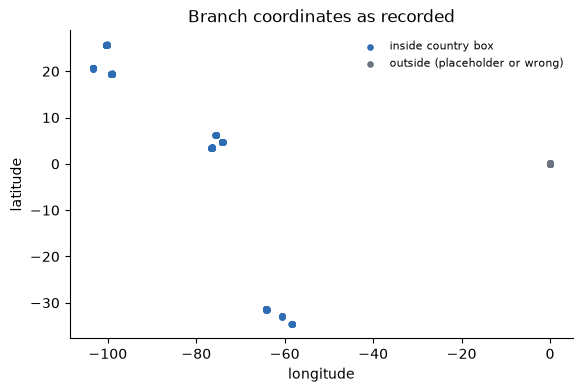

In [3]:
COUNTRY_BOUNDING_BOXES = {
    "México": (14.0, 33.0, -118.5, -86.0),
    "Colombia": (-4.5, 13.5, -79.5, -66.5),
    "Argentina": (-55.5, -21.5, -74.0, -53.0),
}
EXPECTED_PHONE_PREFIX_BY_COUNTRY = {"México": "+52", "Colombia": "+57", "Argentina": "+54"}


def coordinates_inside_country(rows: pd.DataFrame) -> pd.Series:
    """Flags branches whose coordinates fall inside a rough bounding box of their country.

    Exists to detect placeholder or wrong coordinates before any geographic analysis.

    Args:
        rows: Branches with country, latitude and longitude columns.

    Returns:
        pd.Series: True where the coordinates lie inside the country's approximate bounding box.
    """
    boxes = rows["country"].map(COUNTRY_BOUNDING_BOXES)
    return pd.Series(
        [box is not None and box[0] <= lat <= box[1] and box[2] <= lon <= box[3]
         for box, lat, lon in zip(boxes, rows["latitude"], rows["longitude"])],
        index=rows.index,
    )


branches["coordinates_valid"] = coordinates_inside_country(branches)
branches["phone_prefix"] = branches["phone"].str.extract(r"^(\+\d+)")[0]
branches["phone_prefix_valid"] = branches["phone_prefix"] == branches["country"].map(EXPECTED_PHONE_PREFIX_BY_COUNTRY)

display(pd.crosstab(branches["country"], branches["phone_prefix"]))
display(branches.groupby("country").agg(
    branches=("branch_id", "size"),
    valid_phone_prefix=("phone_prefix_valid", "sum"),
    valid_coordinates=("coordinates_valid", "sum"),
))
display(pd.Series({
    "branches with coordinates within 1 degree of (0, 0)": ((branches["latitude"].abs() < 1) & (branches["longitude"].abs() < 1)).sum(),
    "branches with coordinates outside their country's rough box": (~branches["coordinates_valid"]).sum(),
    "branches whose email follows sucursalNNNN@bancolatam.com": branches["email"].str.match(r"^sucursal\d{4}@bancolatam\.com$").sum(),
}, name="count").to_frame())

fig, ax = plt.subplots(figsize=(6.5, 4))
for is_valid, color, label in [(True, BAR_COLOR, "inside country box"), (False, MUTED_COLOR, "outside (placeholder or wrong)")]:
    subset = branches[branches["coordinates_valid"] == is_valid]
    ax.scatter(subset["longitude"], subset["latitude"], s=14, color=color, label=label)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Branch coordinates as recorded")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [4]:
valid_coordinate_spread = (
    branches[branches["coordinates_valid"]].groupby(["country", "city"])
    .agg(branches=("branch_id", "size"), latitude_std_degrees=("latitude", "std"), longitude_std_degrees=("longitude", "std"),
         latitude_range_degrees=("latitude", lambda s: s.max() - s.min()), longitude_range_degrees=("longitude", lambda s: s.max() - s.min()))
)
display(valid_coordinate_spread)
display(pd.Series({
    "cities with at least one valid coordinate": len(valid_coordinate_spread),
    "largest latitude range inside one city, degrees": valid_coordinate_spread["latitude_range_degrees"].max(),
    "largest longitude range inside one city, degrees": valid_coordinate_spread["longitude_range_degrees"].max(),
    "approximate size of 0.1 degree of latitude, km": 11.1,
}, name="value").to_frame())

branches  latitude_std_degrees  longitude_std_degrees  latitude_range_degrees  longitude_range_degrees
country   city                                                                                                                    
Argentina Buenos Aires            11                  0.06                   0.06                    0.18                     0.17
          Córdoba                 20                  0.06                   0.06                    0.19                     0.18
          Rosario                  7                  0.06                   0.04                    0.15                     0.11
Colombia  Bogotá                  22                  0.06                   0.05                    0.19                     0.19
          Cali                    21                  0.06                   0.06                    0.20                     0.20
          Medellín                15                  0.05                   0.06                    0.17                     0.18
México    Ciudad de México        29                  0.05                   0.05                    0.19                     0.17
          Guadalajara             30                  0.05                   0.05                    0.18                     0.20
          Monterrey               28                  0.06                   0.05                    0.19                     0.18

,value
cities with at least one valid coordinate,9.00
"largest latitude range inside one city, degrees",0.20
"largest longitude range inside one city, degrees",0.20
"approximate size of 0.1 degree of latitude, km",11.10


**Mexican branches all carry Argentina's +54 phone prefix** (the same defect seen in customers' phones), and a large share of
coordinates are **placeholders near (0, 0)**, i.e. in the Atlantic. Geographic analysis of the network (distance to customers,
catchment areas, gaps in coverage) is therefore not possible from this file without repairing coordinates first.
Coordinates are also **missing for whole cities**: valid values exist for only **9 of the 16 cities** (none for Puebla, Tijuana,
Querétaro, Barranquilla, Cartagena, La Plata or Mendoza). Where they are valid, the branches of a city fall inside a box of at
most 0.20 degrees (about 22 km; standard deviation 0.05-0.06 degrees), so they are at city scale.

## 3. Network structure: capacity and density per city

,branches,mean_atms,mean_tellers,temporarily_closed
branch_type,,,,
Corporate,129,4.91,8.54,5
Express,130,5.13,7.25,6
Main,43,5.33,7.77,2
Premium,48,5.12,7.60,1


branches  atms  teller_windows  temporarily_closed  customers  customers_per_branch  atms_per_1000_customers  tellers_per_1000_customers
country   city                                                                                                                                                      
Argentina Córdoba                 20   118             147                   1       5792                289.60                    20.37                       25.38
          Mendoza                 16    90             127                   0       5959                372.44                    15.10                       21.31
          La Plata                16    84             122                   2       5973                373.31                    14.06                       20.43
México    Puebla                  33   161             238                   1      12400                375.76                    12.98                       19.19
Colombia  Barranquilla            24   104             170                   0       9076                378.17                    11.46                       18.73
          Cartagena               23   101             195                   0       8956                389.39                    11.28                       21.77
          Bogotá                  22   112             192                   2       9140                415.45                    12.25                       21.01
México    Guadalajara             30   168             243                   0      12643                421.43                    13.29                       19.22
Colombia  Cali                    21   111             144                   2       8972                427.24                    12.37                       16.05
México    Tijuana                 29   154             225                   1      12489                430.66                    12.33                       18.02
          Ciudad de México        29   130             242                   1      12506                431.24                    10.40                       19.35
          Monterrey               28   159             226                   2      12369                441.75                    12.85                       18.27
          Querétaro               26   136             211                   0      12500                480.77                    10.88                       16.88
Argentina Buenos Aires            11    56              81                   1       6037                548.82                     9.28                       13.42
Colombia  Medellín                15    66             126                   0       9107                607.13                     7.25                       13.84
Argentina Rosario                  7    26              55                   1       6081                868.71                     4.28                        9.04

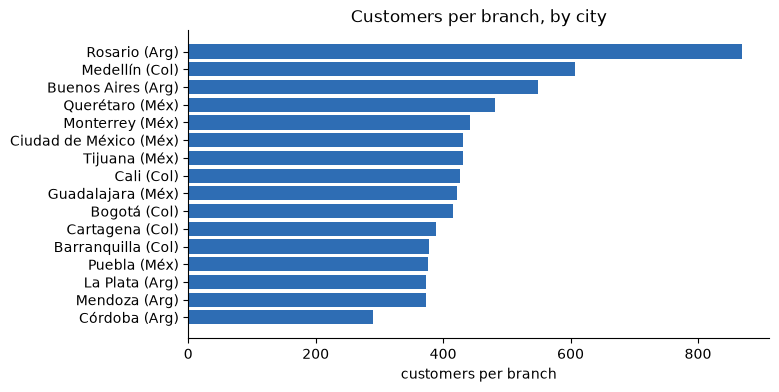

,value
customers per branch: lowest city,289.60
customers per branch: highest city,868.71
ratio highest / lowest,3.00


,min,max
"customers per city, by country",,
Argentina,5792,6081
Colombia,8956,9140
México,12369,12643


In [5]:
by_type = branches.groupby("branch_type").agg(
    branches=("branch_id", "size"), mean_atms=("atm_count", "mean"), mean_tellers=("teller_window_count", "mean"),
    temporarily_closed=("branch_status", lambda s: (s == "Temporarily Closed").sum()),
)
display(by_type)

customers_per_city = customers.groupby(["country", "city"]).size().rename("customers")
network = branches.groupby(["country", "city"]).agg(
    branches=("branch_id", "size"), atms=("atm_count", "sum"), teller_windows=("teller_window_count", "sum"),
    temporarily_closed=("branch_status", lambda s: (s == "Temporarily Closed").sum()),
).join(customers_per_city)
network["customers_per_branch"] = network["customers"] / network["branches"]
network["atms_per_1000_customers"] = network["atms"] / network["customers"] * 1000
network["tellers_per_1000_customers"] = network["teller_windows"] / network["customers"] * 1000
display(network.sort_values("customers_per_branch"))

ordered = network["customers_per_branch"].sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh([f"{city} ({country[:3]})" for country, city in ordered.index], ordered.values, color=BAR_COLOR)
ax.set_xlabel("customers per branch")
ax.set_title("Customers per branch, by city")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
display(pd.Series({
    "customers per branch: lowest city": ordered.iloc[0],
    "customers per branch: highest city": ordered.iloc[-1],
    "ratio highest / lowest": ordered.iloc[-1] / ordered.iloc[0],
}, name="value").to_frame())
display(customers_per_city.groupby(level=0).agg(["min", "max"]).rename_axis("customers per city, by country"))

Customers are spread almost evenly over the cities of each country (about 5,800-6,100 per Argentine city, 9,000-9,100
per Colombian city, 12,400-12,600 per Mexican city), but **branches are not**: customers per branch range from ~290
(Córdoba) to ~870 (Rosario), a ratio of about 3. ATM and teller capacity per 1,000 customers varies in the same way. This
is a structural imbalance in the network itself. Whether it matters depends on whether customers actually use the branch
of their city, which sections 4 and 5 test.

## 4. Links between branches and the rest of the data

In [6]:
branch_ids = set(branches["branch_id"])
product_branches = products.merge(branches[["branch_id", "country", "city", "branch_opening_date", "branch_status"]],
                                  left_on="opening_branch_id", right_on="branch_id", how="left", suffixes=("", "_branch"))
product_branches = product_branches.merge(customers[["customer_id", "country", "city"]], on="customer_id", suffixes=("_branch", "_customer"))
complaint_branches = complaints.dropna(subset=["related_branch_id"]).merge(
    branches[["branch_id", "country"]], left_on="related_branch_id", right_on="branch_id", how="left"
).merge(customers[["customer_id", "country"]], on="customer_id", suffixes=("_branch", "_customer"))

customer_city_share = customers_per_city / customers_per_city.groupby(level=0).transform("sum")
branch_city_counts = branches.groupby(["country", "city"]).size()
branch_city_share = branch_city_counts / branch_city_counts.groupby(level=0).transform("sum")
expected_same_city_by_country = (customer_city_share * branch_city_share).groupby(level=0).sum()
country_weights = customers.groupby("country").size() / len(customers)
chance_same_city = (expected_same_city_by_country * country_weights).sum()

display(pd.Series({
    "products whose opening_branch_id exists in branches.csv (%)": products["opening_branch_id"].isin(branch_ids).mean() * 100,
    "distinct branches used as opening branch": products["opening_branch_id"].nunique(),
    "customers whose registration_branch_id exists in branches.csv": customers["registration_branch_id"].isin(branch_ids).sum(),
    "distinct registration_branch_id values (of 150,000 customers)": customers["registration_branch_id"].nunique(),
    "complaints with a related_branch_id (%)": complaints["related_branch_id"].notna().mean() * 100,
    "  related_branch_id exists in branches.csv (%)": complaints["related_branch_id"].dropna().isin(branch_ids).mean() * 100,
    "product opened at a branch in the owner's country (%)": (product_branches["country_branch"] == product_branches["country_customer"]).mean() * 100,
    "product opened at a branch in the owner's city (%)": (product_branches["city_branch"] == product_branches["city_customer"]).mean() * 100,
    "  expected % if the branch were chosen at random within the country": chance_same_city * 100,
    "complaint's related branch is in the customer's country (%)": (complaint_branches["country_branch"] == complaint_branches["country_customer"]).mean() * 100,
    "products opened before the branch's opening date (%)": (product_branches["opening_date"] < product_branches["branch_opening_date"]).mean() * 100,
}, name="value").to_frame())
display(pd.crosstab(products["opening_channel"], product_branches["country_branch"], normalize="index").mul(100))
display(complaints.groupby("category")["related_branch_id"].agg(lambda s: s.notna().mean() * 100).to_frame("% with a related branch"))

,value
products whose opening_branch_id exists in branches.csv (%),100.00
distinct branches used as opening branch,350.00
customers whose registration_branch_id exists in branches.csv,5.00
"distinct registration_branch_id values (of 150,000 customers)","150,000.00"
complaints with a related_branch_id (%),28.58
related_branch_id exists in branches.csv (%),100.00
product opened at a branch in the owner's country (%),100.00
product opened at a branch in the owner's city (%),18.19
expected % if the branch were chosen at random within the country,18.31
complaint's related branch is in the customer's country (%),37.91


country_branch,Argentina,Colombia,México
opening_channel,,,
App,20.02,30.13,49.85
Branch,19.88,30.01,50.11
Call Center,19.43,30.42,50.15
Web,19.79,29.95,50.26


,% with a related branch
category,
Branch,28.56
Fees,28.91
Service,28.33
Technical,28.36
Transactions,28.75


- **Products** link cleanly to a branch (all 350 are used) and the opening branch is always in the owner's **country**,
  but the **city** matches only about as often as random choice within the country would give. The opening branch is also
  recorded for products opened by app, web and call center, so it is not necessarily where the customer went.
- **Customers** cannot be linked to a registration branch: their `registration_branch_id` is different for every customer
  (150,000 distinct values) and matches the branch file only a handful of times.
- **Complaints** name a related branch in only ~29% of cases, at the same rate for every category (including the `Branch`
  category), and that branch is in the customer's country only about as often as chance.
- ~5% of products were opened before their branch existed.

## 5. Demand per branch: full transaction history (streamed)

In [7]:
def summarize_partition(path: Path, branch_hours: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Reduces one daily transaction file to the small tables this analysis needs.

    Exists so the full history can be scanned one file at a time without ever holding all transactions in memory.

    Args:
        path: Path of one daily transactions file.
        branch_hours: Opening and closing hour of every branch, indexed by branch_id.

    Returns:
        tuple: (transactions and amount per channel and currency, recorded USD amounts per currency for the implied
        exchange rate, transactions per branch, channel and month, transactions per channel, hour and inside-hours flag).
    """
    frame = pd.read_csv(path, usecols=TRANSACTION_COLUMNS)
    all_channels = frame.groupby(["channel", "currency"]).agg(transactions=("amount", "size"), amount=("amount", "sum"))
    recorded = frame.dropna(subset=["amount_usd"]).groupby("currency").agg(amount=("amount", "sum"), amount_usd=("amount_usd", "sum"))
    at_branch = frame[frame["branch_id"].notna()].copy()
    at_branch["month"] = at_branch["transaction_date"].str[:7]
    per_branch = at_branch.groupby(["branch_id", "channel", "month"]).size().rename("transactions")
    stamp = pd.to_datetime(at_branch["transaction_date"])
    at_branch["hour_of_day"] = stamp.dt.hour
    clock = stamp.dt.hour + stamp.dt.minute / 60
    at_branch["inside_opening_hours"] = (clock >= at_branch["branch_id"].map(branch_hours["opening_hour"])) & (
        clock <= at_branch["branch_id"].map(branch_hours["closing_hour"]))
    hours = at_branch.groupby(["channel", "hour_of_day", "inside_opening_hours"]).size().rename("transactions")
    return all_channels, recorded, per_branch.reset_index(), hours.reset_index()


branch_hours = branches.set_index("branch_id")[["opening_hour", "closing_hour"]]
partition_files = sorted(TRANSACTIONS_ROOT.glob("year=*/month=*/day=*/transactions_*.csv"))
channel_parts, recorded_parts, branch_parts, hour_parts = [], [], [], []
peak_memory_mb = current_memory_mb()
for path in partition_files:
    all_channels, recorded, per_branch, hours = summarize_partition(path, branch_hours)
    channel_parts.append(all_channels.reset_index())
    recorded_parts.append(recorded.reset_index())
    branch_parts.append(per_branch)
    hour_parts.append(hours)
    peak_memory_mb = max(peak_memory_mb, current_memory_mb())

channel_totals = pd.concat(channel_parts).groupby(["channel", "currency"]).sum()
recorded_totals = pd.concat(recorded_parts).groupby("currency").sum()
branch_month = pd.concat(branch_parts).groupby(["branch_id", "channel", "month"], as_index=False)["transactions"].sum()
hour_profile = pd.concat(hour_parts).groupby(["channel", "hour_of_day", "inside_opening_hours"], as_index=False)["transactions"].sum()
del channel_parts, recorded_parts, branch_parts, hour_parts

UNITS_PER_USD = (recorded_totals["amount"] / recorded_totals["amount_usd"]).round(2).to_dict()
UNITS_PER_USD["USD"] = 1.0
display(pd.Series({
    "daily files read": len(partition_files),
    "transactions": channel_totals["transactions"].sum(),
    "transactions carrying a branch_id": branch_month["transactions"].sum(),
    "peak process memory while streaming, MB": peak_memory_mb,
    "implied units per USD": str(UNITS_PER_USD),
}, name="value").to_frame())

,value
daily files read,1097
transactions,4425008
transactions carrying a branch_id,1387932
"peak process memory while streaming, MB",359.37
implied units per USD,"{'ARS': 350.0, 'COP': 4000.0, 'USD': 1.0}"


In [8]:
channel_totals = channel_totals.reset_index()
channel_totals["amount_usd_equivalent"] = channel_totals["amount"] / channel_totals["currency"].map(UNITS_PER_USD)
channel_mix = channel_totals.groupby("channel").agg(transactions=("transactions", "sum"), amount_usd_equivalent=("amount_usd_equivalent", "sum"))
channel_mix["share_of_transactions_pct"] = channel_mix["transactions"] / channel_mix["transactions"].sum() * 100
channel_mix["share_of_value_pct"] = channel_mix["amount_usd_equivalent"] / channel_mix["amount_usd_equivalent"].sum() * 100
display(channel_mix.sort_values("transactions", ascending=False))

opening_channel_mix = (products["opening_channel"].value_counts(normalize=True) * 100).to_frame("% of products opened through this channel")
display(opening_channel_mix)
display(branch_month.groupby("channel")["transactions"].sum().to_frame("transactions with a branch_id"))

,transactions,amount_usd_equivalent,share_of_transactions_pct,share_of_value_pct
channel,,,,
POS,1548161,"2,594,302,514.03",34.99,35.00
ATM,1328334,"2,223,608,628.12",30.02,30.00
Web,663445,"1,111,274,326.16",14.99,14.99
App,663414,"1,112,488,396.73",14.99,15.01
Branch,132495,"222,478,432.82",2.99,3.00
Transfer,89159,"148,626,152.37",2.01,2.00


,% of products opened through this channel
opening_channel,
Branch,49.96
Web,25.07
App,19.93
Call Center,5.04


,transactions with a branch_id
channel,
ATM,1262007
Branch,125925


Only `ATM` and `Branch` transactions carry a `branch_id`. Teller (`Branch`) transactions are **~3% of all transactions**, by
count and by value, while `ATM` is ~30%; but the **Branch is the opening channel of 50% of products**. In this data the
physical branch is mainly an acquisition channel, and ATMs are the physical transaction channel.

In [9]:
branch_totals = (
    branch_month.pivot_table(index="branch_id", columns="channel", values="transactions", aggfunc="sum", fill_value=0)
    .rename(columns={"ATM": "atm_transactions", "Branch": "teller_transactions"})
)
branch_totals["transactions"] = branch_totals.sum(axis=1)
branch_demand = branches.set_index("branch_id").join(branch_totals)
days_in_history = len(partition_files)
branch_demand["atm_transactions_per_atm_per_day"] = branch_demand["atm_transactions"] / branch_demand["atm_count"] / days_in_history
branch_demand["teller_transactions_per_window_per_day"] = branch_demand["teller_transactions"] / branch_demand["teller_window_count"] / days_in_history

display(branch_demand[["atm_transactions", "teller_transactions", "transactions", "atm_transactions_per_atm_per_day",
                       "teller_transactions_per_window_per_day"]].describe())
mean_transactions = branch_demand["transactions"].mean()
display(pd.Series({
    "transactions per branch: mean": mean_transactions,
    "transactions per branch: std observed": branch_demand["transactions"].std(),
    "transactions per branch: std expected from chance alone (sqrt of mean)": mean_transactions ** 0.5,
    "highest / lowest branch": branch_demand["transactions"].max() / branch_demand["transactions"].min(),
}, name="value").to_frame())

,atm_transactions,teller_transactions,transactions,atm_transactions_per_atm_per_day,teller_transactions_per_window_per_day
count,350.00,350.00,350.00,350.00,350.00
mean,"3,605.73",359.79,"3,965.52",0.79,0.05
std,61.56,19.88,64.96,0.39,0.02
min,"3,440.00",311.00,"3,774.00",0.39,0.02
25%,"3,561.00",346.00,"3,923.00",0.47,0.03
50%,"3,607.00",360.00,"3,963.00",0.65,0.04
75%,"3,646.00",372.00,"4,005.75",1.08,0.06
max,"3,815.00",421.00,"4,177.00",1.71,0.12


,value
transactions per branch: mean,"3,965.52"
transactions per branch: std observed,64.96
transactions per branch: std expected from chance alone (sqrt of mean),62.97
highest / lowest branch,1.11


,branches,mean,ci_95
mean transactions per branch by atm_count,,,
2,44,"3,964.34",17.19
3,52,"3,969.52",15.20
4,53,"3,981.40",18.70
5,46,"3,955.04",18.47
6,49,"3,972.76",18.89
7,52,"3,955.96",19.17
8,54,"3,958.61",17.63


,branches,mean,ci_95
mean transactions per branch by branch_type,,,
Corporate,129,"3,968.95",10.99
Express,130,"3,972.08",11.26
Main,43,"3,959.16",19.69
Premium,48,"3,944.21",17.83


,branches,mean,ci_95
mean transactions per branch by branch_status,,,
Active,336,"3,966.28",6.99
Temporarily Closed,14,"3,947.29",27.60


,branches,mean,ci_95
mean transactions per branch by country,,,
Argentina,70,"3,942.61",15.21
Colombia,105,"3,969.81",12.12
México,175,"3,972.11",9.52


,branches,mean,ci_95
mean transactions per branch by age_band,,,
<10 y,77,"3,971.52",15.11
10-20 y,99,"3,960.08",12.75
20-30 y,102,"3,959.61",12.48
30+ y,72,"3,974.96",14.54


,Spearman with transactions per branch
atm_count,-0.06
teller_window_count,-0.01
age_years,0.01


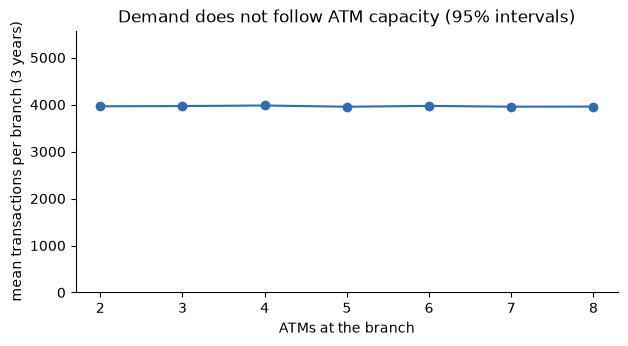

In [10]:
def mean_with_interval(frame: pd.DataFrame, group: str, value: str) -> pd.DataFrame:
    """Summarises a measure by group with a 95% half-width for the mean.

    Exists so differences between branch groups can be judged against their noise.

    Args:
        frame: One row per branch.
        group: Column to group by.
        value: Numeric column to summarise.

    Returns:
        pd.DataFrame: branches, mean and 95% half-width of the mean per group.
    """
    grouped = frame.groupby(group, observed=True)[value].agg(branches="size", mean="mean", std="std")
    grouped["ci_95"] = 1.96 * grouped["std"] / grouped["branches"] ** 0.5
    return grouped.drop(columns="std")


branch_demand["age_band"] = pd.cut(branch_demand["age_years"], [0, 10, 20, 30, 40], labels=["<10 y", "10-20 y", "20-30 y", "30+ y"])
for group in ["atm_count", "branch_type", "branch_status", "country", "age_band"]:
    display(mean_with_interval(branch_demand, group, "transactions").rename_axis(f"mean transactions per branch by {group}"))

display(branch_demand[["transactions", "atm_count", "teller_window_count", "age_years"]].corr(method="spearman")["transactions"]
        .drop("transactions").to_frame("Spearman with transactions per branch"))
by_atm_count = mean_with_interval(branch_demand, "atm_count", "transactions")
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.errorbar(by_atm_count.index.astype(str), by_atm_count["mean"], yerr=by_atm_count["ci_95"], fmt="o-",
            color=BAR_COLOR, ecolor=MUTED_COLOR, capsize=3)
ax.set_ylim(0, by_atm_count["mean"].max() * 1.4)
ax.set_xlabel("ATMs at the branch")
ax.set_ylabel("mean transactions per branch (3 years)")
ax.set_title("Demand does not follow ATM capacity (95% intervals)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Demand is the same at every branch.** The spread of transactions per branch equals what chance alone would produce, and it
does not follow ATM count, teller windows, branch type, status, country or age. A branch with 8 ATMs sees no more
transactions than one with 2, so **volume per ATM varies about four-fold** purely because of how many ATMs were installed.

### Opening hours

inside_opening_hours,False,True,share_inside_opening_hours_pct
channel,,,
ATM,763504,498503,39.50
Branch,75997,49928,39.65


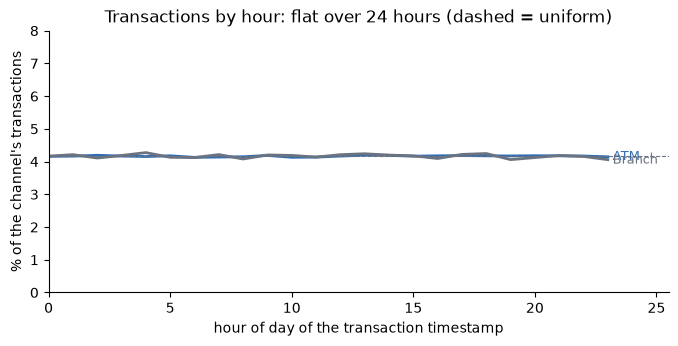

,opening_hour,closing_hour,open_hours
count,350.00,350.00,350.00
mean,8.81,18.26,9.46
std,0.57,1.11,1.23
min,8.00,17.00,7.50
25%,8.50,17.00,8.50
50%,9.00,18.00,9.50
75%,9.50,19.00,10.50
max,9.50,20.00,12.00


In [11]:
inside_share = hour_profile.groupby(["channel", "inside_opening_hours"])["transactions"].sum().unstack()
inside_share["share_inside_opening_hours_pct"] = inside_share[True] / inside_share.sum(axis=1) * 100
display(inside_share)

profile = hour_profile.groupby(["channel", "hour_of_day"])["transactions"].sum().unstack(0)
share_by_hour = profile / profile.sum() * 100
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(share_by_hour.index, share_by_hour["ATM"], color=BAR_COLOR, linewidth=2)
ax.plot(share_by_hour.index, share_by_hour["Branch"], color=MUTED_COLOR, linewidth=2)
ax.text(23.2, share_by_hour["ATM"].iloc[-1], "ATM", color=BAR_COLOR, va="center", fontsize=9)
ax.text(23.2, share_by_hour["Branch"].iloc[-1], "Branch", color=MUTED_COLOR, va="center", fontsize=9)
ax.axhline(100 / 24, color=MUTED_COLOR, linewidth=0.8, linestyle="--")
ax.set_ylim(0, 8)
ax.set_xlim(0, 25.5)
ax.set_xlabel("hour of day of the transaction timestamp")
ax.set_ylabel("% of the channel's transactions")
ax.set_title("Transactions by hour: flat over 24 hours (dashed = uniform)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
display(branches[["opening_hour", "closing_hour"]].assign(open_hours=lambda t: t["closing_hour"] - t["opening_hour"]).describe())

Teller (`Branch`) transactions happen at all 24 hours with equal frequency, so only about 40% fall inside the branch's
opening hours; a teller transaction at 3 a.m. is not plausible. Opening hours therefore **cannot be optimised or even
validated** against this transaction data.

## 6. Temporarily closed branches

In [12]:
closed_summary = pd.DataFrame({
    "branches": branches.groupby("branch_status").size(),
    "transactions per branch (3 years)": branch_demand.groupby("branch_status")["transactions"].mean(),
    "products opened per branch": products.groupby("opening_branch_id").size().rename("products").to_frame().join(
        branches.set_index("branch_id")["branch_status"]).groupby("branch_status")["products"].mean(),
    "complaints with this related branch, per branch": complaints.groupby("related_branch_id").size().rename("complaints").to_frame().join(
        branches.set_index("branch_id")["branch_status"]).groupby("branch_status")["complaints"].mean(),
})
display(closed_summary)

last_months = sorted(branch_month["month"].unique())[-6:]
recent = branch_month[branch_month["month"].isin(last_months)].merge(branches[["branch_id", "branch_status"]], on="branch_id")
monthly_per_branch = recent.groupby(["month", "branch_status"])["transactions"].sum().unstack() / branches["branch_status"].value_counts()
display(monthly_per_branch.rename_axis("transactions per branch, last 6 months (June is partial)"))
display(pd.Series({
    "products opened at temporarily closed branches": (product_branches["branch_status"] == "Temporarily Closed").sum(),
    "  of which still open products (status Active)": ((product_branches["branch_status"] == "Temporarily Closed") & (product_branches["product_status"] == "Active")).sum(),
}, name="count").to_frame())

,branches,transactions per branch (3 years),products opened per branch,"complaints with this related branch, per branch"
branch_status,,,,
Active,336,"3,966.28","1,142.96",54.69
Temporarily Closed,14,"3,947.29","1,140.50",57.36


branch_status,Active,Temporarily Closed
"transactions per branch, last 6 months (June is partial)",,
2026-01,109.15,111.14
2026-02,102.78,98.50
2026-03,111.06,111.43
2026-04,113.63,115.14
2026-05,114.03,110.43
2026-06,63.76,62.64


,count
products opened at temporarily closed branches,15967
of which still open products (status Active),13574


The 14 `Temporarily Closed` branches show **the same activity as open ones**: same transactions per branch, the same in
each of the last six months, same products opened and complaints. Either the closure is not reflected in the activity data
or the status is not reliable; the file has no closure date to tell which.

## 7. Products, delinquency and complaints by branch

In [13]:
def spread_versus_chance(counts: pd.Series) -> pd.Series:
    """Compares the spread of a per-branch count with what random allocation would give.

    Exists to test whether some branches really stand out.

    Args:
        counts: One count per branch.

    Returns:
        pd.Series: mean, observed standard deviation, chance standard deviation and their ratio.
    """
    return pd.Series({
        "mean per branch": counts.mean(), "std observed": counts.std(),
        "std expected from chance": counts.mean() ** 0.5, "ratio observed / expected": counts.std() / counts.mean() ** 0.5,
    })


products_per_branch = products.groupby("opening_branch_id").size().reindex(branches["branch_id"], fill_value=0)
complaints_per_branch = complaints.groupby("related_branch_id").size().reindex(branches["branch_id"], fill_value=0)
branch_products_by_channel = products[products["opening_channel"] == "Branch"].groupby("opening_branch_id").size().reindex(branches["branch_id"], fill_value=0)

credit = products.dropna(subset=["days_past_due"]).assign(is_delinquent=lambda t: t["days_past_due"] > 0)
delinquency_per_branch = credit.groupby("opening_branch_id")["is_delinquent"].agg(rate="mean", credit_products="size")
overall_rate = credit["is_delinquent"].mean()
delinquency_spread = pd.Series({
    "credit products per branch (mean)": delinquency_per_branch["credit_products"].mean(),
    "delinquency rate: overall": overall_rate * 100,
    "delinquency rate across branches: std observed (points)": delinquency_per_branch["rate"].std() * 100,
    "std expected from chance (points)": (overall_rate * (1 - overall_rate) / delinquency_per_branch["credit_products"]).mean() ** 0.5 * 100,
    "lowest / highest branch rate (%)": f"{delinquency_per_branch['rate'].min() * 100:.1f} / {delinquency_per_branch['rate'].max() * 100:.1f}",
}, name="value")

display(pd.DataFrame({
    "products opened per branch (any channel)": spread_versus_chance(products_per_branch),
    "products opened per branch through the Branch channel": spread_versus_chance(branch_products_by_channel),
    "complaints naming the branch": spread_versus_chance(complaints_per_branch),
}))
display(delinquency_spread.to_frame())

branch_profile = branches.set_index("branch_id").assign(
    products=products_per_branch, complaints=complaints_per_branch, delinquency_rate=delinquency_per_branch["rate"] * 100
)
display(branch_profile[["products", "complaints", "delinquency_rate", "atm_count", "teller_window_count", "age_years"]]
        .corr(method="spearman").loc[["products", "complaints", "delinquency_rate"], ["atm_count", "teller_window_count", "age_years"]])
display(branch_profile.groupby("branch_type")[["products", "complaints", "delinquency_rate"]].mean())

,products opened per branch (any channel),products opened per branch through the Branch channel,complaints naming the branch
mean per branch,"1,142.86",570.97,54.79
std observed,33.70,22.48,7.70
std expected from chance,33.81,23.89,7.40
ratio observed / expected,1.00,0.94,1.04


,value
credit products per branch (mean),358.14
delinquency rate: overall,14.97
delinquency rate across branches: std observed (points),1.88
std expected from chance (points),1.89
lowest / highest branch rate (%),10.6 / 21.0


,atm_count,teller_window_count,age_years
products,-0.02,-0.08,0.01
complaints,0.01,0.11,0.01
delinquency_rate,-0.00,0.03,-0.10


,products,complaints,delinquency_rate
branch_type,,,
Corporate,"1,142.98",55.05,14.86
Express,"1,143.54",54.06,15.02
Main,"1,147.49",54.84,15.19
Premium,"1,136.52",56.06,14.97


Products opened, delinquency and complaints per branch all vary **exactly as much as chance predicts** (ratio to the chance
spread ~1), and do not follow capacity, age or branch type. **No branch is a hot spot** for complaints or delinquency, and no
branch is a star for acquisition.

## 8. Baseline

In [14]:
baseline = pd.Series({
    "branches (Mexico / Colombia / Argentina)": " / ".join(str(branches["country"].value_counts()[c]) for c in ["México", "Colombia", "Argentina"]),
    "ATMs / teller windows in the network": f"{branches['atm_count'].sum():,} / {branches['teller_window_count'].sum():,}",
    "temporarily closed branches": (branches["branch_status"] == "Temporarily Closed").sum(),
    "customers per branch: lowest / highest city": f"{ordered.iloc[0]:.0f} / {ordered.iloc[-1]:.0f}",
    "ATM transactions per ATM per day (mean)": branch_demand["atm_transactions_per_atm_per_day"].mean(),
    "teller transactions per window per day (mean)": branch_demand["teller_transactions_per_window_per_day"].mean(),
    "teller share of all transactions, %": channel_mix.loc["Branch", "share_of_transactions_pct"],
    "ATM share of all transactions, %": channel_mix.loc["ATM", "share_of_transactions_pct"],
    "products opened through the Branch channel, %": (products["opening_channel"] == "Branch").mean() * 100,
    "branches with valid coordinates": int(branches["coordinates_valid"].sum()),
    "branches with valid phone prefix": int(branches["phone_prefix_valid"].sum()),
}, name="baseline")
display(baseline.to_frame())

,baseline
branches (Mexico / Colombia / Argentina),175 / 105 / 70
ATMs / teller windows in the network,"1,776 / 2,744"
temporarily closed branches,14
customers per branch: lowest / highest city,290 / 869
ATM transactions per ATM per day (mean),0.79
teller transactions per window per day (mean),0.05
"teller share of all transactions, %",2.99
"ATM share of all transactions, %",30.02
"products opened through the Branch channel, %",49.96
branches with valid coordinates,183


## 9. Conclusions

**Short answer.** The branch file describes a network with real structural imbalances, but **nothing the branches are
attributed with (transactions, products opened, complaints, delinquency) differs between branches beyond chance**, and
much of the location and linkage data is unusable. The opportunities are therefore about **repairing the data and
validating the imbalances**, not about identifying better or worse branches.

**What is a fact about the network (from `branches.csv` and customers)**

- 350 branches (175 Mexico, 105 Colombia, 70 Argentina), 1,776 ATMs and 2,744 teller windows; 14 branches (4%) are `Temporarily Closed`.
- Customers are spread evenly across the cities of each country, but branches are not: **customers per branch range from
  290 (Córdoba) to 869 (Rosario), a 3.0x ratio**; ATMs per 1,000 customers from 20.4 (Córdoba) to 4.3 (Rosario), with
  Medellín (607 customers per branch, 7.3 ATMs per 1,000) and Buenos Aires (549, 9.3) also stretched.

**What the activity data says**

- **Demand is identical at every branch.** Transactions per branch: mean 3,966, spread 65 against 63 expected from chance,
  highest / lowest branch 1.11. Products opened per branch: 1,143 (spread 33.7 vs 33.8 by chance). Complaints naming the
  branch: spread 7.7 vs 7.4 by chance. Delinquency by opening branch: spread 1.88 vs 1.89 points by chance. None follows ATM
  count, teller windows, branch type, status, country or age (Spearman about -0.06 to 0.1).
- **Capacity varies, demand does not.** ATMs per branch range 2-8 but a branch with 8 ATMs sees the same volume as one with 2
  (3,959 vs 3,964), so ATM transactions per ATM per day range 0.39-1.71 (mean 0.79); teller windows see 0.05 per window per day.
  These are relative comparisons only: whether the transaction file is the complete activity is not known.
- **Physical channels.** Teller transactions are 3.0% of all transactions (by count and by value), ATM 30.0%, while the Branch is
  the opening channel of 50.0% of products.
- **Temporarily closed branches look open.** Same transactions per branch (3,947 vs 3,966), same monthly volume in the last six
  months, 15,967 products opened there (13,574 still `Active`) and more complaints per branch (57.4 vs 54.7).
- **Hours.** Transactions occur equally at all 24 hours and only 39.6% of teller transactions fall inside the branch's
  opening hours.

**What is unusable without repair**

- Coordinates: 167 of 350 (48%) are placeholders near (0, 0) or outside their country, and 7 of the 16 cities have no valid
  coordinate at all. All 175 Mexican branches carry
  Argentina's +54 phone prefix.
- `registration_branch_id` in customers matches the branch file 5 times in 150,000 customers. Complaints name a branch in only
  28.6% of cases (the same for every category), and the opening branch of a product is in the owner's city exactly as often
  as chance (18.2% vs 18.3%).
- ~4.8% of products were opened before their branch existed.

**What this means.** No branch is a hot spot or a star, so there is nothing to rank. The measurable levers are (1) repairing
locations and links so a coverage and catchment analysis becomes possible, (2) validating whether the density imbalance and
the uneven ATM allocation are real, and (3) clarifying the status of the 14 closed branches. The value of any of them cannot be
sized here: no cost, revenue, footfall or staffing data exists in these files.